In [91]:
import pandas as pd
from matplotlib import pyplot as plt

In [96]:
station_df

,pre,tm,tmax,tmin,mb,gr,ep,dis,time,dsk,hsg,kq,slglk,tgzlk,wlwt,xhl
time,,,,,,,,,,,,,,,,
2000-01-31 00:00:00,1.995997,-9.553845,-3.680238,-15.020368,3.830147,0.0,NaN,23.290323,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-02-29 00:00:00,3.330357,-7.075148,-0.632522,-13.219049,1.842741,0.0,NaN,25.310345,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-03-31 00:00:00,3.433956,1.065857,7.800601,-5.698651,1.091076,0.0,NaN,24.396774,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-04-30 00:00:00,11.098143,9.863503,15.985115,3.711913,0.972954,0.0,NaN,29.353333,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-05-31 00:00:00,20.095877,14.939283,21.498005,8.610401,1.799675,5220000.0,NaN,125.874194,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2100-08-31 00:00:00,75.226483,21.777031,30.414107,14.957859,8.534994,296000000.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2100-09-30 00:00:00,33.899863,17.511357,26.301221,10.356590,-10.154905,42700000.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2100-10-31 00:00:00,20.071738,9.710036,16.048830,4.823963,-50.523479,211000.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN


                  pre         tm          ep         dis            gr
time                                                                  
2000-01-31   1.995997  -9.553845         NaN   23.290323  0.000000e+00
2000-02-29   3.330357  -7.075148         NaN   25.310345  0.000000e+00
2000-03-31   3.433956   1.065857         NaN   24.396774  0.000000e+00
2000-04-30  11.098143   9.863503         NaN   29.353333  0.000000e+00
2000-05-31  20.095877  14.939283         NaN  125.874194  5.572314e+06
2000-06-30  32.134506  16.288230  392.170402  284.130000  4.978768e+08
2000-07-31  34.919890  18.124691  497.053757  622.903226  1.043600e+09
2000-08-31  19.852627  16.877223  690.012094  520.677419  1.200176e+09
2000-09-30  26.971720  12.736307  182.160480  195.766667  1.819772e+07
2000-10-31   5.757603   4.884766   48.999704   62.058065  0.000000e+00
                  pre         tm          ep         dis            gr
time                                                                  
2000-0

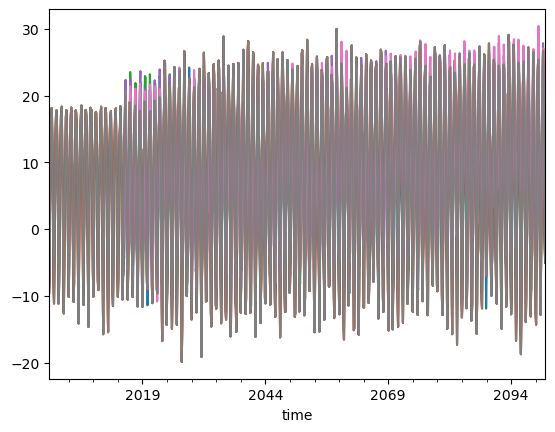

In [111]:
for scenario in ['ssp126','ssp245','ssp370','ssp585']:
    
    station_df = pd.read_csv(r'F:\geodata\river_runoff_obs\3_xhl_imputMF_future_month_2000_2100.csv')
    station_df.drop(columns=['tmax', 'tmin', 'mb', 'gr'], inplace=True)
    station_df['time'] = pd.to_datetime(station_df['time'])
    station_df.set_index('time', inplace=True)
    station_df.index = station_df.index.to_period('M').to_timestamp('M')
    
    # add glacier runoff
    gr_df = pd.read_csv(f"I:\\GlacierData\\glacier_mon_pre\\R131415_glac_runoff_fixed_monthly_1set_2000_2100-{scenario}-Batch.csv")
    gr_df['time'] = pd.to_datetime(gr_df['time'])
    gr_df.set_index('time', inplace=True)
    gr_df.index = gr_df.index.to_period('M').to_timestamp('M')
    
    station_df = station_df.merge(gr_df['xhl'], how='left', left_index=True, right_index=True)
    station_df.rename(columns={'xhl': 'gr'}, inplace=True)
    
    tas_df = pd.read_csv(f"J:\\CMIP6_r1i1p1f1\\variable_model_df\\tas_day_AWI-CM-1-1-MR_{scenario}_r1i1p1f1.csv")
    pr_df  = pd.read_csv(f"J:\\CMIP6_r1i1p1f1\\variable_model_df\\pr_day_AWI-CM-1-1-MR_{scenario}_r1i1p1f1.csv")
    tas_df['time'] = pd.to_datetime(tas_df['time'])
    pr_df['time'] = pd.to_datetime(pr_df['time'])
    tas_df.set_index('time', inplace=True)
    pr_df.set_index('time', inplace=True)
    tas_df -= 273.15 # Convert to Celsius temperature
    mon_tas_df = tas_df.resample('ME').mean()
    mon_pr_df = pr_df.resample('ME').sum()
    mon_tas_df.index = mon_tas_df.index.to_period('M').to_timestamp('M')
    mon_pr_df.index = mon_pr_df.index.to_period('M').to_timestamp('M')
    
    
    station_future_df = pd.merge(mon_tas_df['xhl'],mon_tas_df['xhl'],left_index=True,right_index=True,suffixes=('tm','pre'))
    station_future_df.columns = ['tm_CMIP6','pre_CMIP6']
    # station_df # Here, historical climate data is obtained from CN05.
    merged_df = pd.merge(station_df, station_future_df ,how='left',left_index=True, right_index=True)
    
    # Here we only minus the bias without other processing
    overlap_df = merged_df.loc[(merged_df.index >= '2015-01-01') & (merged_df.index <= '2019-12-31')]
    bias_tm = overlap_df.tm_CMIP6.mean() - overlap_df.tm.mean()
    bias_pr = overlap_df.pre_CMIP6.mean() - overlap_df.pre.mean()
    station_future_df['tm_CMIP6']  -= bias_tm
    station_future_df['pre_CMIP6'] -= bias_pr
    station_future_df['tm_CMIP6'].plot()
    station_df['tm'].plot()
    station_df.loc['2019-01-01':,'tm'] = station_future_df.loc['2019-01-01':,'tm_CMIP6']
    station_df.loc['2019-01-01':,'pre'] = station_future_df.loc['2019-01-01':,'pre_CMIP6']
    
    print(station_df.head(10))
    station_df.to_csv(f'F:\\geodata\\river_runoff_obs\\3_xhl_AWI-CM-1-1-MR_{scenario}_r1i1p1f1.csv')